In [1]:
%reload_ext autoreload
%autoreload 2

import sys
sys.path.insert(0, "..")

In [2]:
import pandas as pd
import torch.nn as nn

from src.utils.paths import AUDIO_DIR
from src.features.dataset import load_metadata, make_dataset, make_work_level_dataset
from src.model.nn_model import cross_validate_feature_model

In [3]:
metadata_filtered = load_metadata()

print(
    metadata_filtered.groupby("composer")["work_id"]
    .nunique()
    .sort_values()
)

composer
Brahms        8
Schubert      9
Mozart       11
Bach         30
Beethoven    55
Name: work_id, dtype: int64


# Formiranje X, y, groups

In [ ]:
X, y, groups = make_dataset(
    metadata_filtered,
    AUDIO_DIR,
)

print("X:", X.shape)
print("y:", y.shape)
print("groups:", groups.shape)

Processing (grouped):   0%|          | 0/302 [00:00<?, ?it/s]

c:\Users\marko.vucic_ominimo\Desktop\music-classifier\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Processing (grouped):   0%|          | 0/302 [00:31<?, ?it/s]


KeyboardInterrupt: 

# Isprobavanje potpuno povezanih mreza

<span style="font-size:20px">
Naime, sada cemo isprobati neke potpuno povezane mreze, zbog malog skupa podataka ne ocekujemo previse od njih, ali cemo ih svakako probati. Uglavnom cemo koristiti manje mreze jer bi se vece overfitovale na ovako malom skupu podataka, a svakako nije iskljuceno da ce se to desiti ni sa manjim arhitekturama. 

Mozemo problem posmatrati kao do sada sa podjelom kompozicija na audio segmente, i predvidjanje autora kompozicije na osnovu majority voting-a odradjenog na svim audio segmentima jedne kompozicije. Dakle, princip ostaje isti kao i kod klasicnih modela masinskog ucenja. Takodje cemo isprobati i akumuliranje feature vektora svih segmenata jedne kompozicije u jedan feature vektor za cijelu kompoziciju, sto moze potencijalno biti povoljno za neuronsku mrezu jer nece puno vidjeti isti segment iste kompozicije (sjetimo se da imamo u nasem skupu podataka vise puta istu kompoziciju samo sa razlicitim stavom). 
</span>

In [ ]:
class SegmentNeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 32),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(32, 8),
            nn.ReLU(),
            nn.Dropout(0.3),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


SegmentNeuralNetwork | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/20 | train_loss=0.8461 | val_loss=1.0619 | train_acc=0.6722 | val_acc=0.5419
Epoch 10/20 | train_loss=0.6648 | val_loss=1.1611 | train_acc=0.7416 | val_acc=0.5633
Epoch 15/20 | train_loss=0.5523 | val_loss=1.2707 | train_acc=0.7668 | val_acc=0.5735
Epoch 20/20 | train_loss=0.4939 | val_loss=1.4666 | train_acc=0.7939 | val_acc=0.5713


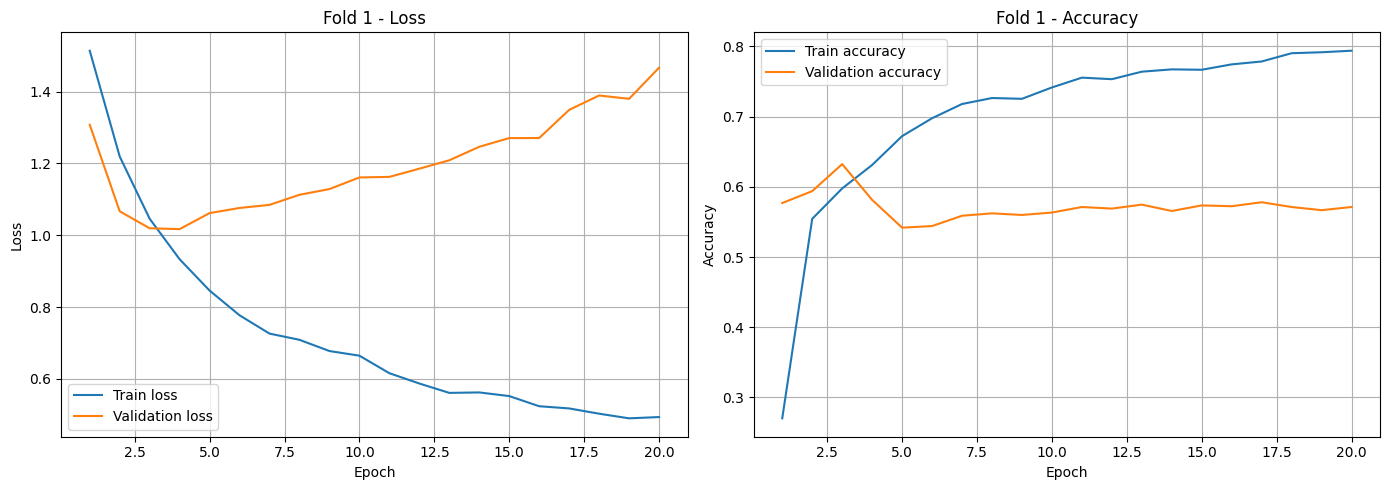

Fold 1: accuracy=0.6364, macro F1=0.3267

========== FOLD 2 ==========
Epoch 5/20 | train_loss=0.9064 | val_loss=1.1114 | train_acc=0.6488 | val_acc=0.5629
Epoch 10/20 | train_loss=0.7456 | val_loss=1.0952 | train_acc=0.7186 | val_acc=0.5798
Epoch 15/20 | train_loss=0.6381 | val_loss=1.0792 | train_acc=0.7581 | val_acc=0.6376
Epoch 20/20 | train_loss=0.5508 | val_loss=1.0960 | train_acc=0.8000 | val_acc=0.6546


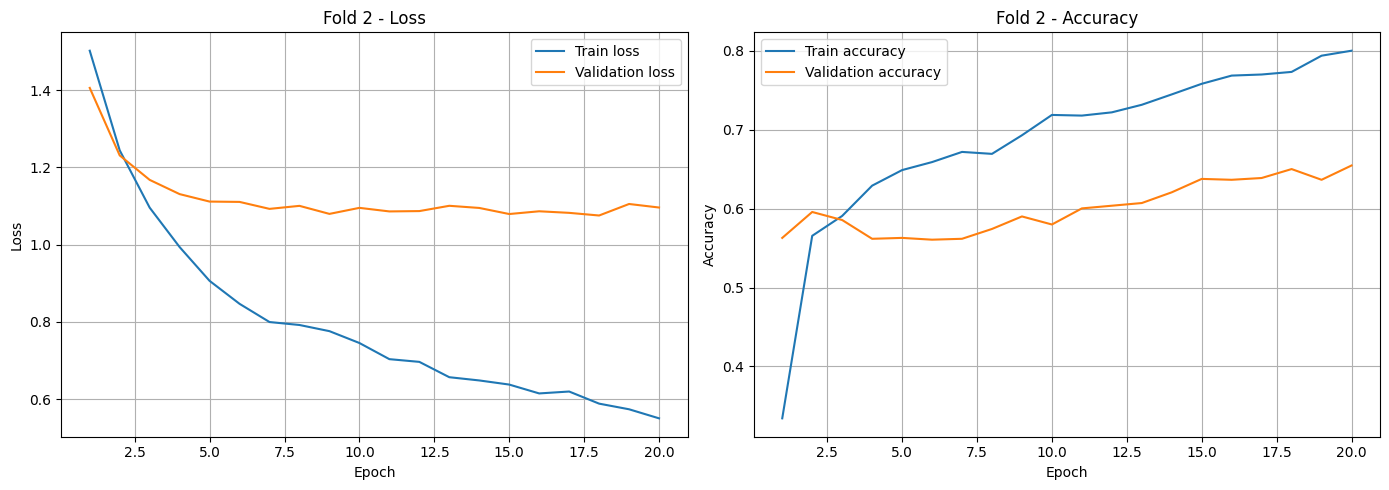

Fold 2: accuracy=0.6818, macro F1=0.3349

========== FOLD 3 ==========
Epoch 5/20 | train_loss=0.9753 | val_loss=1.1858 | train_acc=0.6458 | val_acc=0.5711
Epoch 10/20 | train_loss=0.6773 | val_loss=1.3294 | train_acc=0.7477 | val_acc=0.6313
Epoch 15/20 | train_loss=0.5574 | val_loss=1.4467 | train_acc=0.7925 | val_acc=0.6794
Epoch 20/20 | train_loss=0.5079 | val_loss=1.6850 | train_acc=0.8074 | val_acc=0.6729


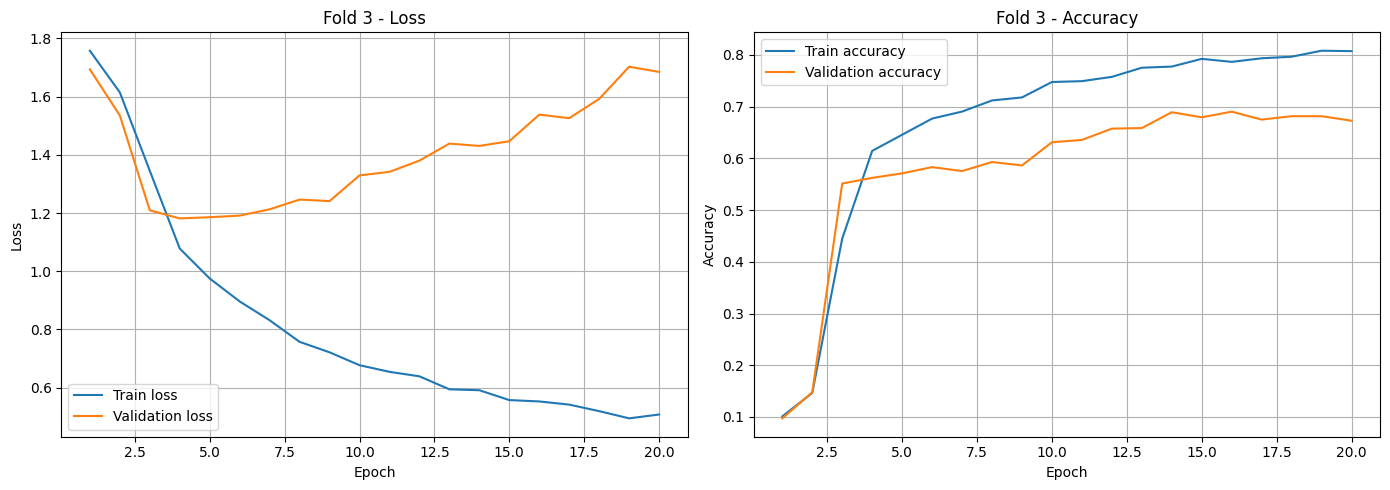

Fold 3: accuracy=0.8182, macro F1=0.6467

========== FOLD 4 ==========
Epoch 5/20 | train_loss=0.8752 | val_loss=1.0371 | train_acc=0.6632 | val_acc=0.6216
Epoch 10/20 | train_loss=0.6720 | val_loss=1.0009 | train_acc=0.7329 | val_acc=0.6575
Epoch 15/20 | train_loss=0.5744 | val_loss=1.0191 | train_acc=0.7644 | val_acc=0.6638
Epoch 20/20 | train_loss=0.5145 | val_loss=1.1575 | train_acc=0.7968 | val_acc=0.6533


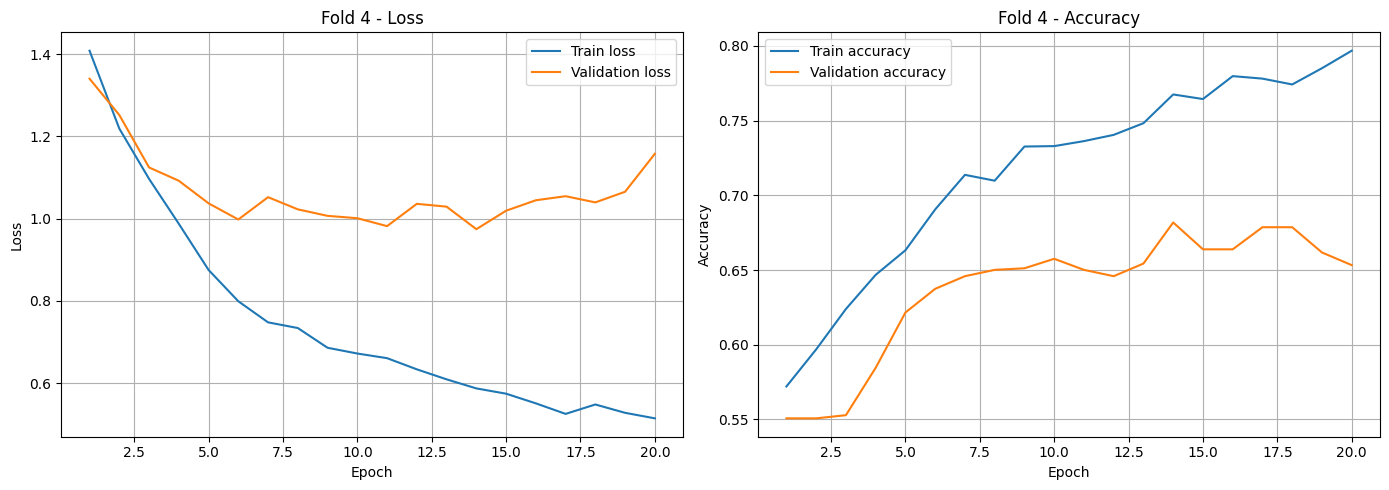

Fold 4: accuracy=0.7826, macro F1=0.4809

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.8361 | val_loss=1.0890 | train_acc=0.6650 | val_acc=0.6071
Epoch 10/20 | train_loss=0.6243 | val_loss=1.1950 | train_acc=0.7273 | val_acc=0.6391
Epoch 15/20 | train_loss=0.5018 | val_loss=1.3665 | train_acc=0.8012 | val_acc=0.6313
Epoch 20/20 | train_loss=0.4551 | val_loss=1.5628 | train_acc=0.8241 | val_acc=0.6225


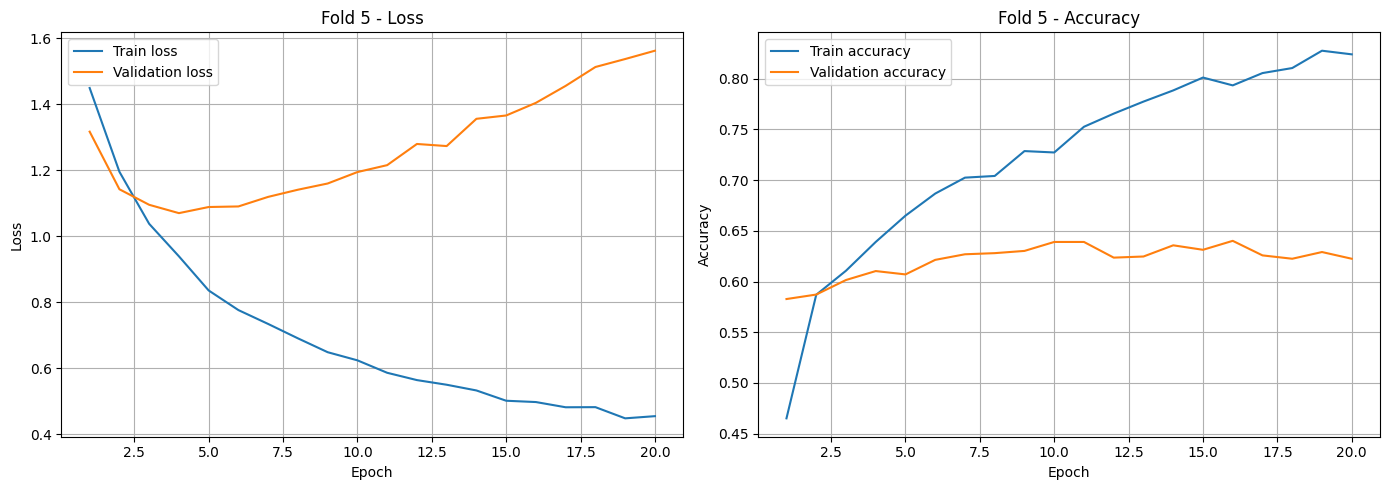

Fold 5: accuracy=0.7500, macro F1=0.5846

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.7338
Mean macro F1: 0.4748
              precision    recall  f1-score   support

        Bach       1.00      0.83      0.91        30
   Beethoven       0.72      0.95      0.82        55
      Brahms       0.20      0.12      0.15         8
      Mozart       0.29      0.18      0.22        11
    Schubert       0.75      0.33      0.46         9

    accuracy                           0.73       113
   macro avg       0.59      0.48      0.51       113
weighted avg       0.72      0.73      0.71       113



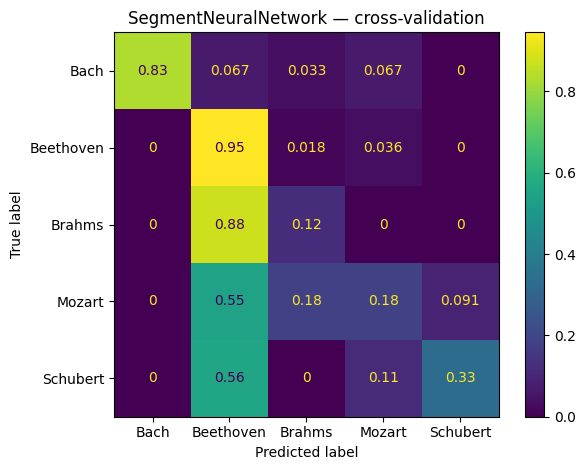

In [ ]:
results_segment = cross_validate_feature_model(
    SegmentNeuralNetwork,
    X, y, groups,
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
)

<span style="font-size:20px">
Mozemo primijetiti znacajno preprilagodjavanje modela neuronske mreze cak i sa ovako malim brojem parametrima, mozemo probati pristup sa dodatnim smanjenjem mreze ili da uvedemo vecu regularizaciju, ili oboje. 
</span>

In [ ]:
class SegmentNeuralNetworkRegularized(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


SegmentNeuralNetworkRegularized | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/20 | train_loss=1.0988 | val_loss=1.0522 | train_acc=0.5813 | val_acc=0.5962
Epoch 10/20 | train_loss=0.9902 | val_loss=0.9801 | train_acc=0.5999 | val_acc=0.5882
Epoch 15/20 | train_loss=0.8989 | val_loss=0.9472 | train_acc=0.6202 | val_acc=0.6063
Epoch 20/20 | train_loss=0.8732 | val_loss=1.0215 | train_acc=0.6429 | val_acc=0.6052


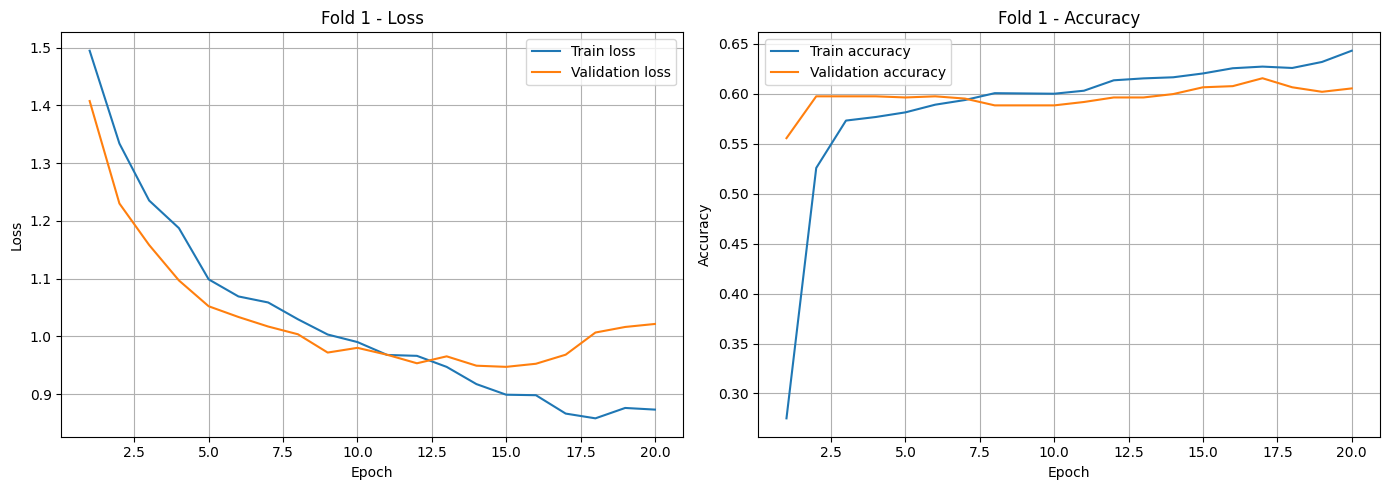

Fold 1: accuracy=0.5455, macro F1=0.2429

========== FOLD 2 ==========
Epoch 5/20 | train_loss=1.1079 | val_loss=1.1855 | train_acc=0.5767 | val_acc=0.5991
Epoch 10/20 | train_loss=0.9266 | val_loss=1.1673 | train_acc=0.6003 | val_acc=0.6172
Epoch 15/20 | train_loss=0.8490 | val_loss=1.1805 | train_acc=0.6529 | val_acc=0.6659
Epoch 20/20 | train_loss=0.8021 | val_loss=1.1783 | train_acc=0.6655 | val_acc=0.6625


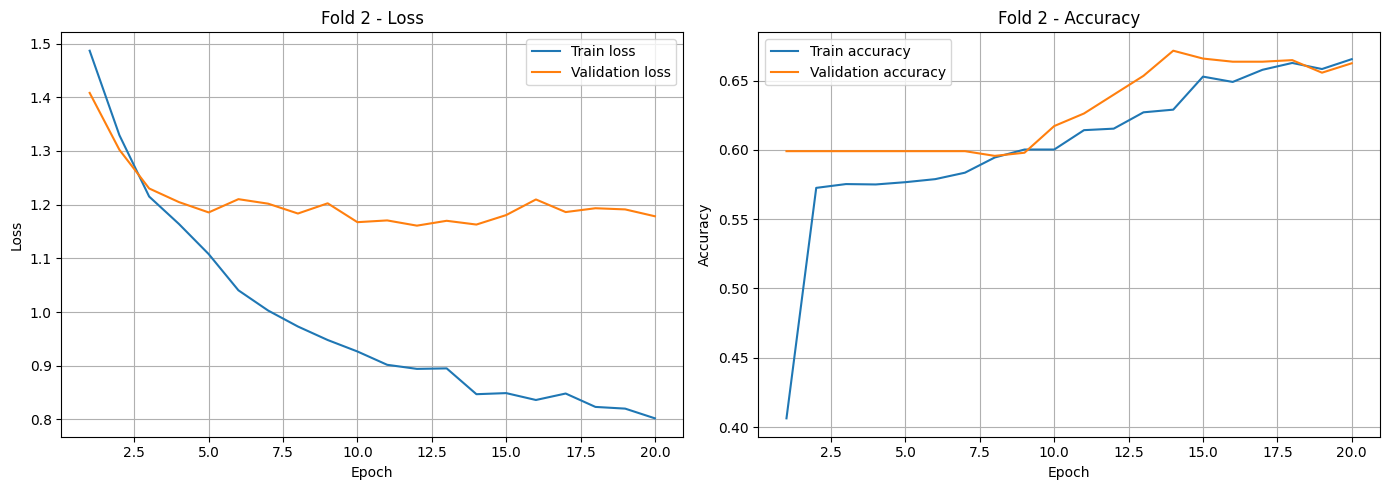

Fold 2: accuracy=0.6818, macro F1=0.3295

========== FOLD 3 ==========
Epoch 5/20 | train_loss=1.0807 | val_loss=1.3473 | train_acc=0.6010 | val_acc=0.6094
Epoch 10/20 | train_loss=0.9153 | val_loss=1.6127 | train_acc=0.6339 | val_acc=0.6138
Epoch 15/20 | train_loss=0.8565 | val_loss=1.9129 | train_acc=0.6452 | val_acc=0.6127
Epoch 20/20 | train_loss=0.8151 | val_loss=2.3274 | train_acc=0.6621 | val_acc=0.5624


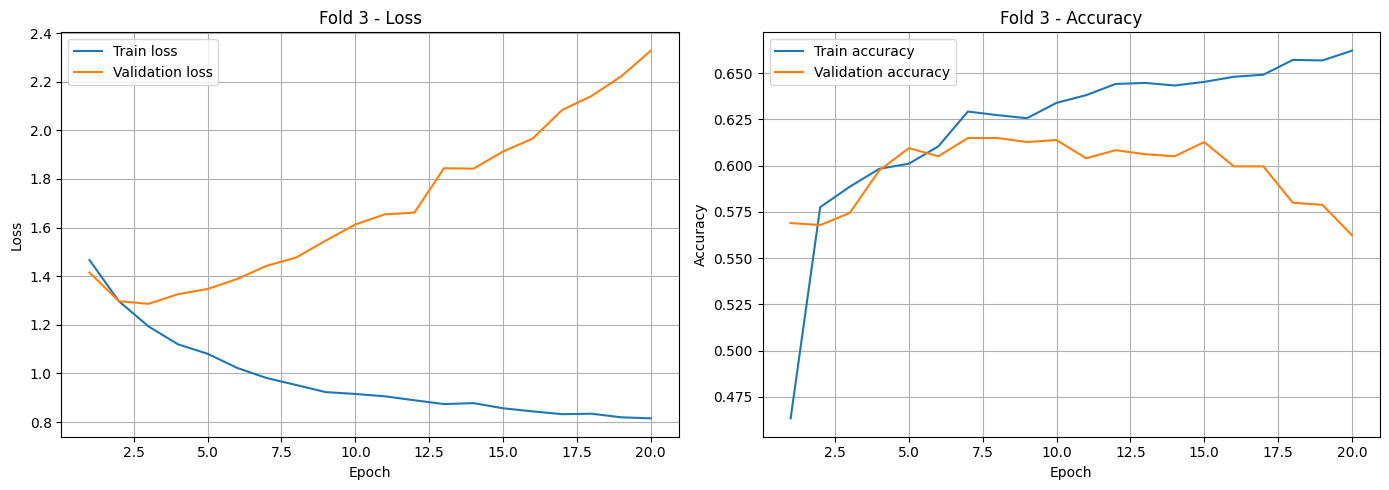

Fold 3: accuracy=0.7273, macro F1=0.3571

========== FOLD 4 ==========
Epoch 5/20 | train_loss=1.1242 | val_loss=1.2361 | train_acc=0.6083 | val_acc=0.5507
Epoch 10/20 | train_loss=0.9522 | val_loss=1.1921 | train_acc=0.6485 | val_acc=0.5772
Epoch 15/20 | train_loss=0.8655 | val_loss=1.1747 | train_acc=0.6627 | val_acc=0.6004
Epoch 20/20 | train_loss=0.8282 | val_loss=1.1856 | train_acc=0.6680 | val_acc=0.6015


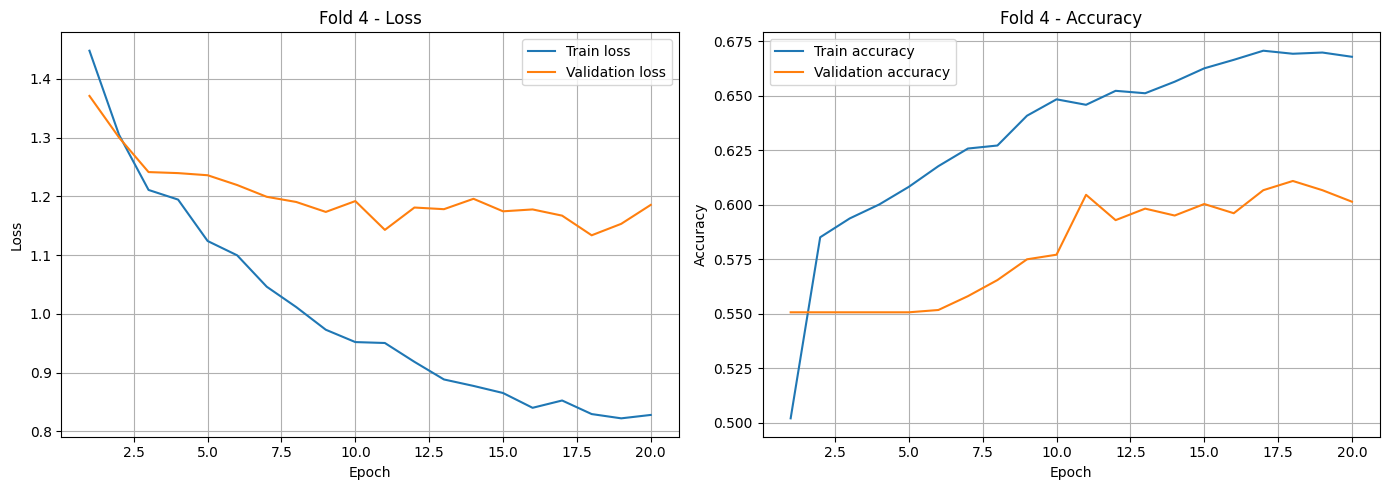

Fold 4: accuracy=0.6957, macro F1=0.3184

========== FOLD 5 ==========
Epoch 5/20 | train_loss=1.1654 | val_loss=1.1657 | train_acc=0.5578 | val_acc=0.5817
Epoch 10/20 | train_loss=0.9572 | val_loss=1.1325 | train_acc=0.6559 | val_acc=0.6358
Epoch 15/20 | train_loss=0.8338 | val_loss=1.1431 | train_acc=0.6890 | val_acc=0.6490
Epoch 20/20 | train_loss=0.7917 | val_loss=1.1417 | train_acc=0.7017 | val_acc=0.6457


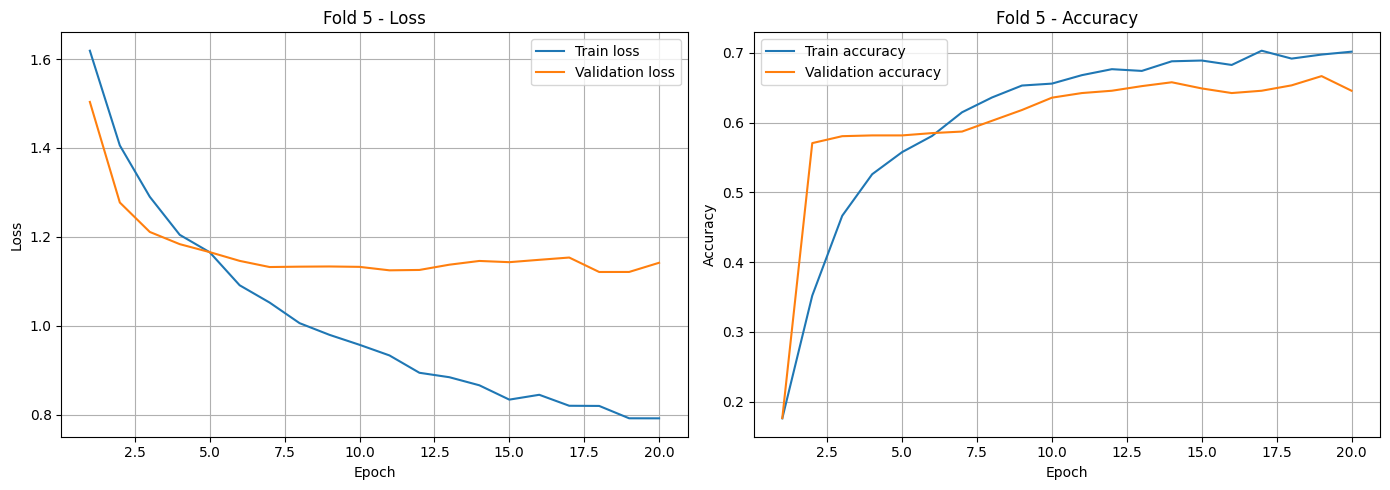

Fold 5: accuracy=0.7083, macro F1=0.4184

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.6717
Mean macro F1: 0.3333
              precision    recall  f1-score   support

        Bach       1.00      0.70      0.82        30
   Beethoven       0.61      0.98      0.76        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.25      0.09      0.13        11
    Schubert       0.00      0.00      0.00         9

    accuracy                           0.67       113
   macro avg       0.37      0.35      0.34       113
weighted avg       0.59      0.67      0.60       113



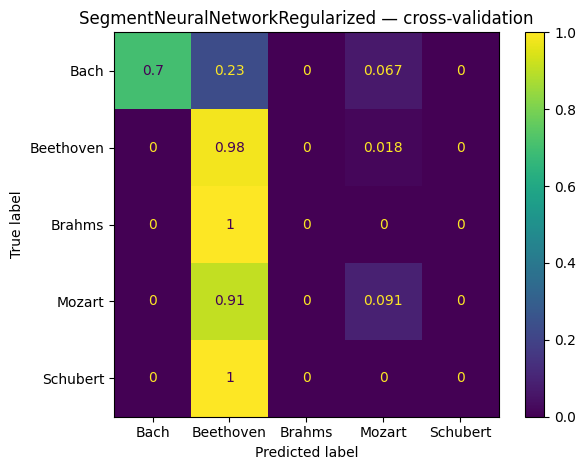

In [ ]:
results_regularized = cross_validate_feature_model(
    SegmentNeuralNetworkRegularized,
    X, y, groups,
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
)

In [ ]:
class SmallSegmentNeuralNetwork(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),

            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


SmallSegmentNeuralNetwork | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/20 | train_loss=0.9650 | val_loss=1.1264 | train_acc=0.6528 | val_acc=0.5543
Epoch 10/20 | train_loss=0.7533 | val_loss=1.1907 | train_acc=0.7218 | val_acc=0.5735
Epoch 15/20 | train_loss=0.6139 | val_loss=1.2212 | train_acc=0.7613 | val_acc=0.6052
Epoch 20/20 | train_loss=0.5465 | val_loss=1.3313 | train_acc=0.7731 | val_acc=0.6052


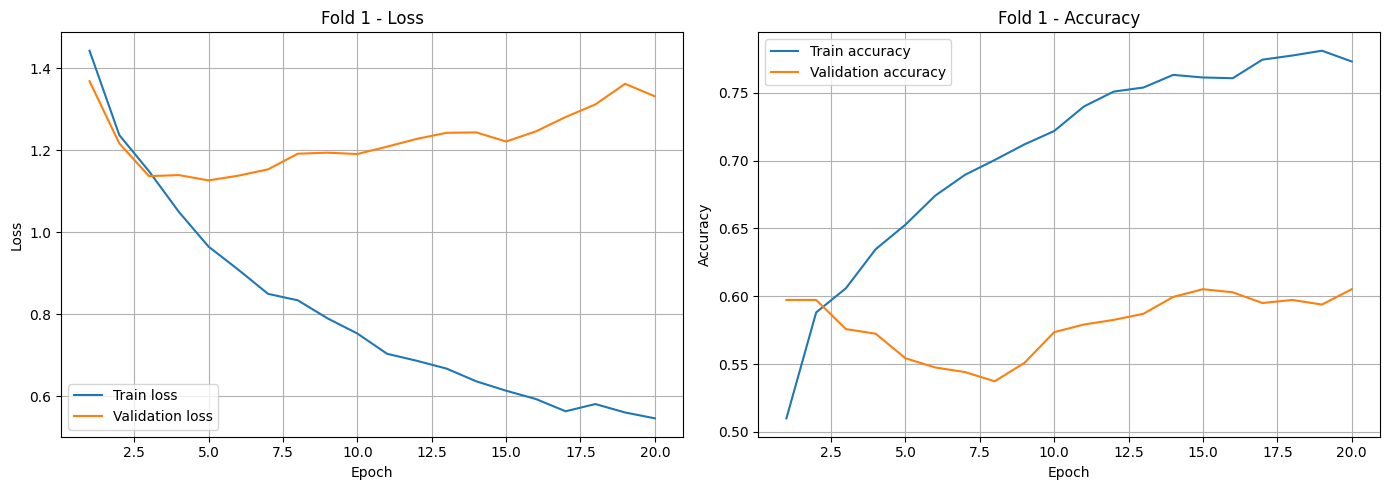

Fold 1: accuracy=0.6364, macro F1=0.3200

========== FOLD 2 ==========
Epoch 5/20 | train_loss=1.0714 | val_loss=1.1786 | train_acc=0.6071 | val_acc=0.5696
Epoch 10/20 | train_loss=0.8851 | val_loss=1.1645 | train_acc=0.6444 | val_acc=0.5527
Epoch 15/20 | train_loss=0.7755 | val_loss=1.1544 | train_acc=0.6671 | val_acc=0.5515
Epoch 20/20 | train_loss=0.6730 | val_loss=1.1274 | train_acc=0.7003 | val_acc=0.5572


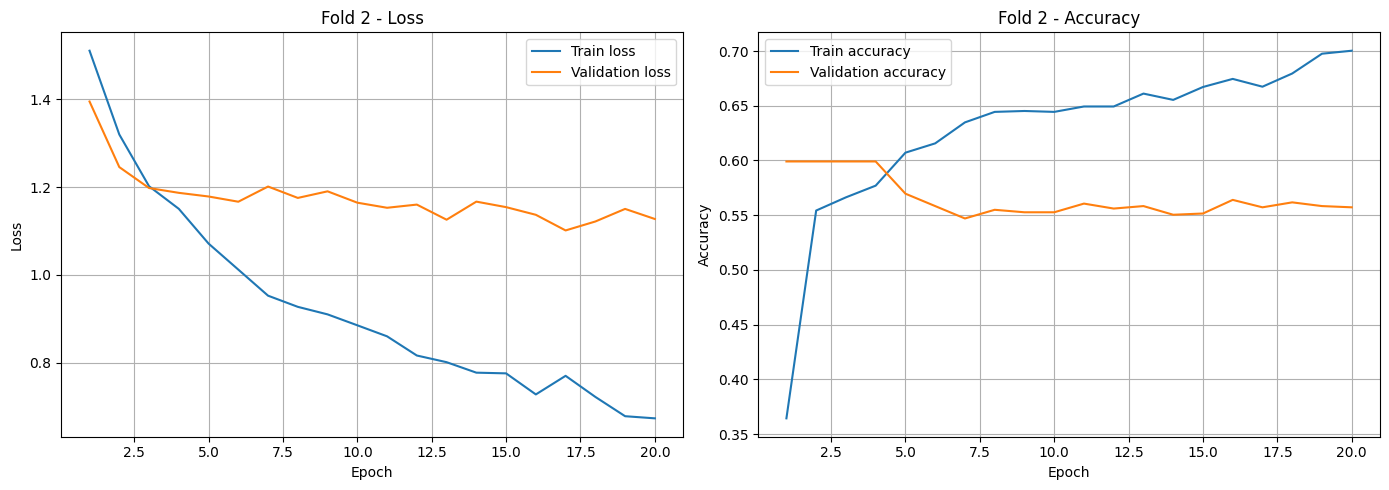

Fold 2: accuracy=0.5455, macro F1=0.2375

========== FOLD 3 ==========
Epoch 5/20 | train_loss=0.9412 | val_loss=1.2611 | train_acc=0.6328 | val_acc=0.5295
Epoch 10/20 | train_loss=0.7030 | val_loss=1.4400 | train_acc=0.7204 | val_acc=0.5799
Epoch 15/20 | train_loss=0.6032 | val_loss=1.5674 | train_acc=0.7450 | val_acc=0.5810
Epoch 20/20 | train_loss=0.5477 | val_loss=1.7878 | train_acc=0.7621 | val_acc=0.6028


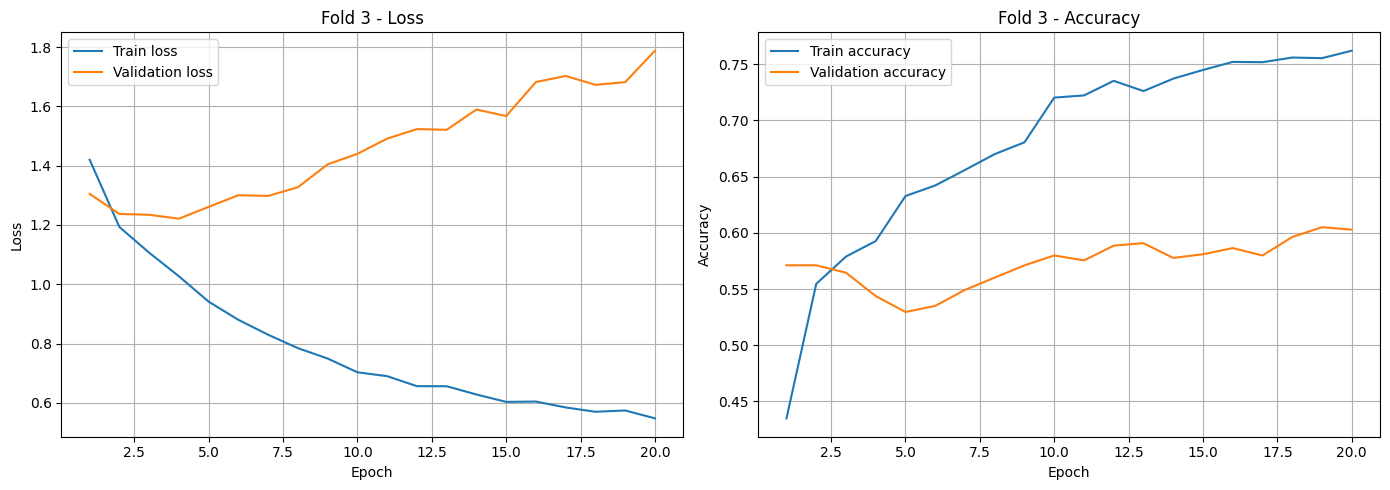

Fold 3: accuracy=0.7727, macro F1=0.4630

========== FOLD 4 ==========
Epoch 5/20 | train_loss=0.9641 | val_loss=1.1232 | train_acc=0.6289 | val_acc=0.6047
Epoch 10/20 | train_loss=0.7723 | val_loss=1.1331 | train_acc=0.6805 | val_acc=0.6195
Epoch 15/20 | train_loss=0.6562 | val_loss=1.1584 | train_acc=0.7301 | val_acc=0.6628
Epoch 20/20 | train_loss=0.5703 | val_loss=1.2547 | train_acc=0.7471 | val_acc=0.6744


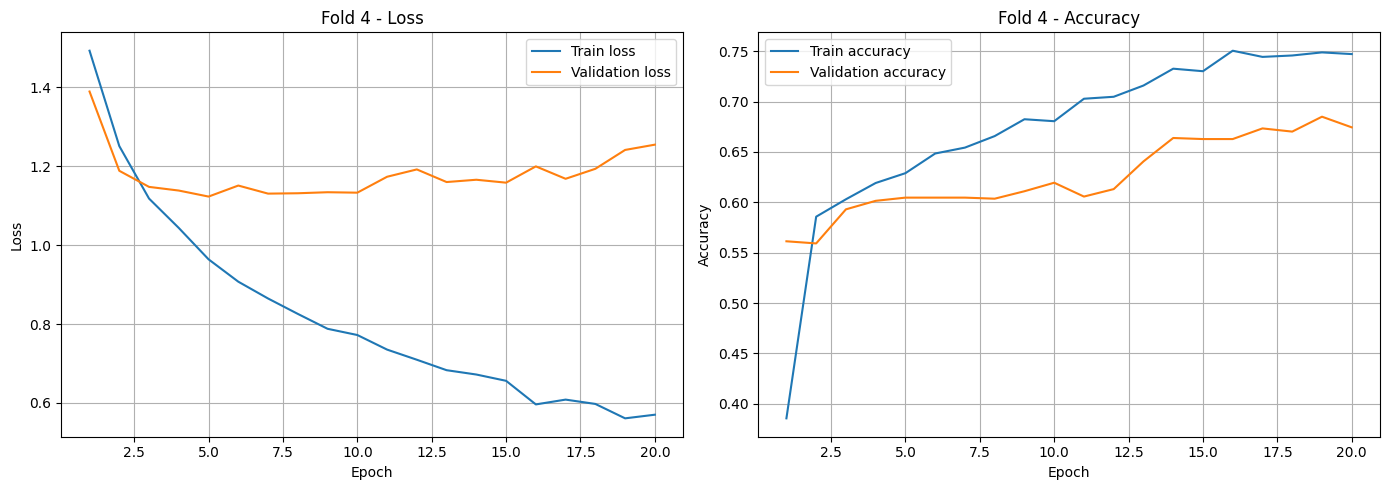

Fold 4: accuracy=0.7826, macro F1=0.4872

========== FOLD 5 ==========
Epoch 5/20 | train_loss=0.9374 | val_loss=1.2461 | train_acc=0.6341 | val_acc=0.5254
Epoch 10/20 | train_loss=0.6996 | val_loss=1.3819 | train_acc=0.7039 | val_acc=0.5684
Epoch 15/20 | train_loss=0.5808 | val_loss=1.3794 | train_acc=0.7276 | val_acc=0.5861
Epoch 20/20 | train_loss=0.5228 | val_loss=1.4282 | train_acc=0.7546 | val_acc=0.6104


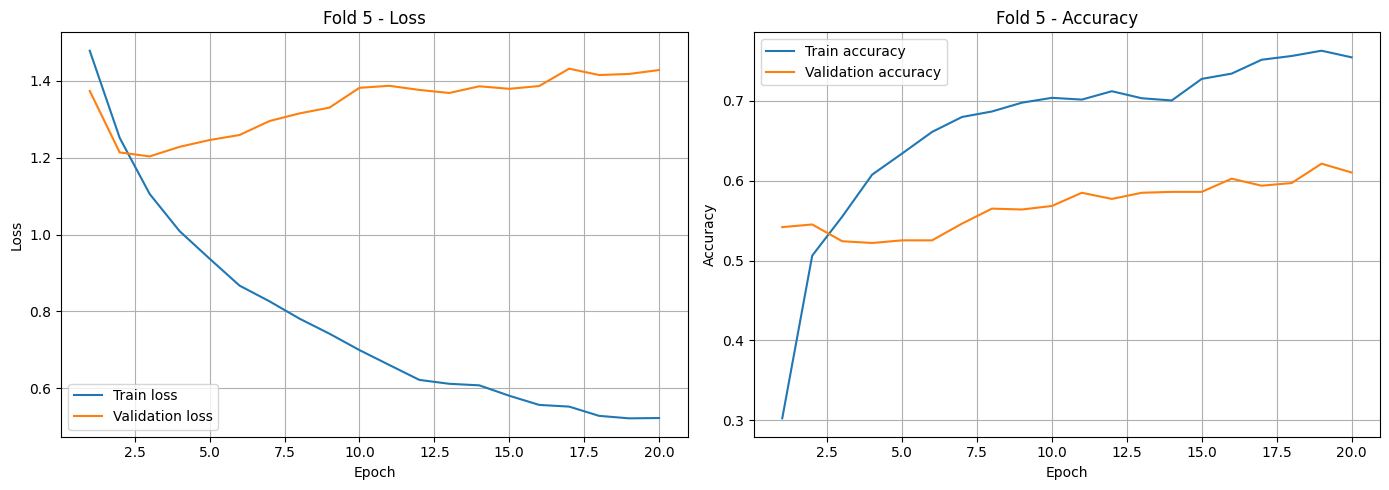

Fold 5: accuracy=0.6667, macro F1=0.3328

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.6808
Mean macro F1: 0.3681
              precision    recall  f1-score   support

        Bach       1.00      0.70      0.82        30
   Beethoven       0.65      0.96      0.77        55
      Brahms       0.25      0.12      0.17         8
      Mozart       0.33      0.18      0.24        11
    Schubert       0.00      0.00      0.00         9

    accuracy                           0.68       113
   macro avg       0.45      0.39      0.40       113
weighted avg       0.63      0.68      0.63       113



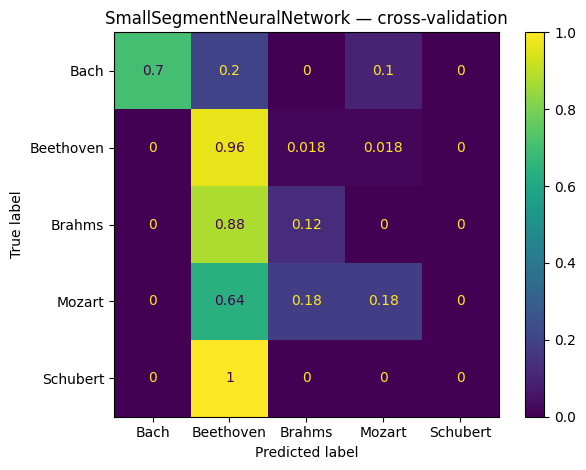

In [ ]:
results_small_segment = cross_validate_feature_model(
    SmallSegmentNeuralNetwork,
    X, y, groups,
    epochs=20,
    batch_size=64,
    learning_rate=0.001,
)

<span style="font-size:20px">
Naime, nijedan od navedenih pristupa nije urodio plodom, u svakom slucaju se neuronska mreza preprilagodjavala. Mozemo pokusati sada klasifikaciju gdje akumuliramo feature vektore svih segmenata u jedan feature vektor koji ce da koristi cijela kompozicija
</span>

In [ ]:
X_work, y_work, work_ids = make_work_level_dataset(X,y,groups)

In [ ]:
class WorkNN_Small(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 16),
            nn.ReLU(),
            nn.Dropout(0.4),

            nn.Linear(16, num_classes)
        )

    def forward(self, x):
        return self.network(x)


WorkNN_Small | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/30 | train_loss=1.1322 | val_loss=1.0283 | train_acc=0.5778 | val_acc=0.6957
Epoch 10/30 | train_loss=0.8631 | val_loss=0.7714 | train_acc=0.7000 | val_acc=0.7391
Epoch 15/30 | train_loss=0.6301 | val_loss=0.6424 | train_acc=0.8222 | val_acc=0.7826
Epoch 20/30 | train_loss=0.6235 | val_loss=0.5887 | train_acc=0.7889 | val_acc=0.7391
Epoch 25/30 | train_loss=0.4885 | val_loss=0.5685 | train_acc=0.8111 | val_acc=0.7826
Epoch 30/30 | train_loss=0.3962 | val_loss=0.5492 | train_acc=0.8556 | val_acc=0.8261


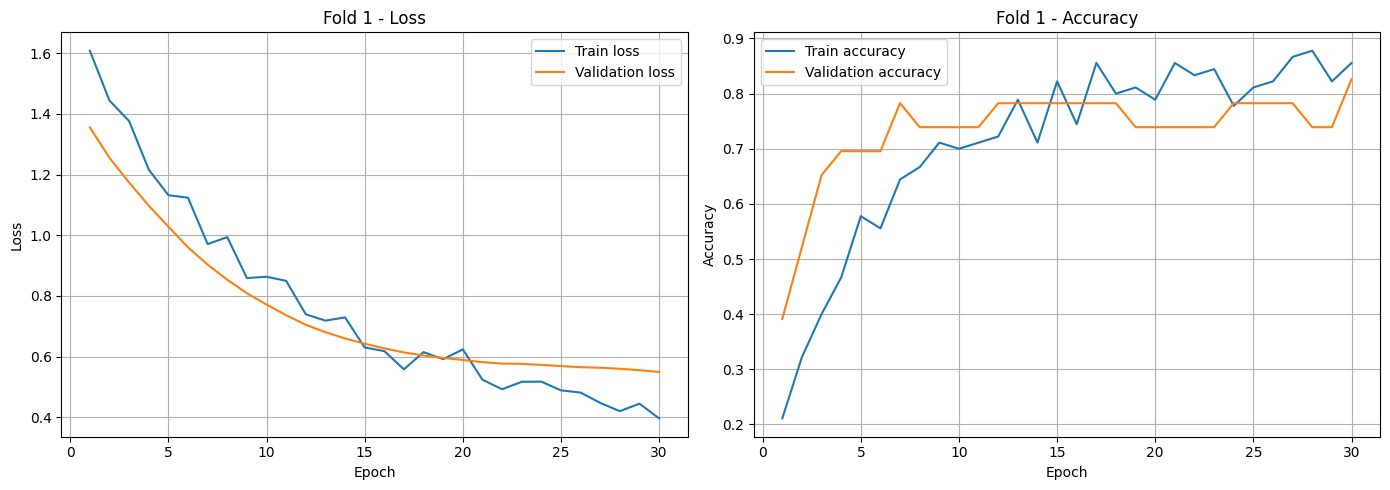

Fold 1: accuracy=0.8261, macro F1=0.5692

========== FOLD 2 ==========
Epoch 5/30 | train_loss=1.0901 | val_loss=1.2735 | train_acc=0.5667 | val_acc=0.4348
Epoch 10/30 | train_loss=0.8011 | val_loss=1.1702 | train_acc=0.7444 | val_acc=0.4348
Epoch 15/30 | train_loss=0.6915 | val_loss=1.1121 | train_acc=0.8222 | val_acc=0.6087
Epoch 20/30 | train_loss=0.5117 | val_loss=1.1221 | train_acc=0.8667 | val_acc=0.6087
Epoch 25/30 | train_loss=0.4486 | val_loss=1.1213 | train_acc=0.8333 | val_acc=0.6087
Epoch 30/30 | train_loss=0.3763 | val_loss=1.1496 | train_acc=0.8889 | val_acc=0.6957


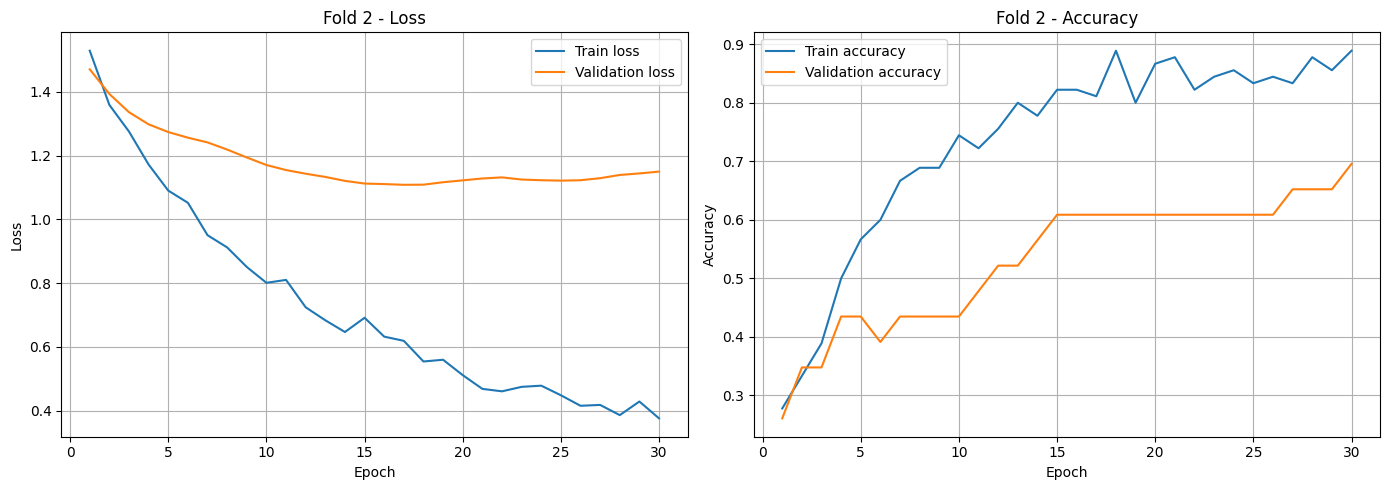

Fold 2: accuracy=0.6957, macro F1=0.4613

========== FOLD 3 ==========
Epoch 5/30 | train_loss=1.0058 | val_loss=0.9414 | train_acc=0.7111 | val_acc=0.6957
Epoch 10/30 | train_loss=0.7199 | val_loss=0.7413 | train_acc=0.7778 | val_acc=0.7391
Epoch 15/30 | train_loss=0.5689 | val_loss=0.6825 | train_acc=0.7889 | val_acc=0.7391
Epoch 20/30 | train_loss=0.4811 | val_loss=0.6356 | train_acc=0.8222 | val_acc=0.7826
Epoch 25/30 | train_loss=0.3943 | val_loss=0.5972 | train_acc=0.8556 | val_acc=0.8261
Epoch 30/30 | train_loss=0.4406 | val_loss=0.5829 | train_acc=0.8000 | val_acc=0.8261


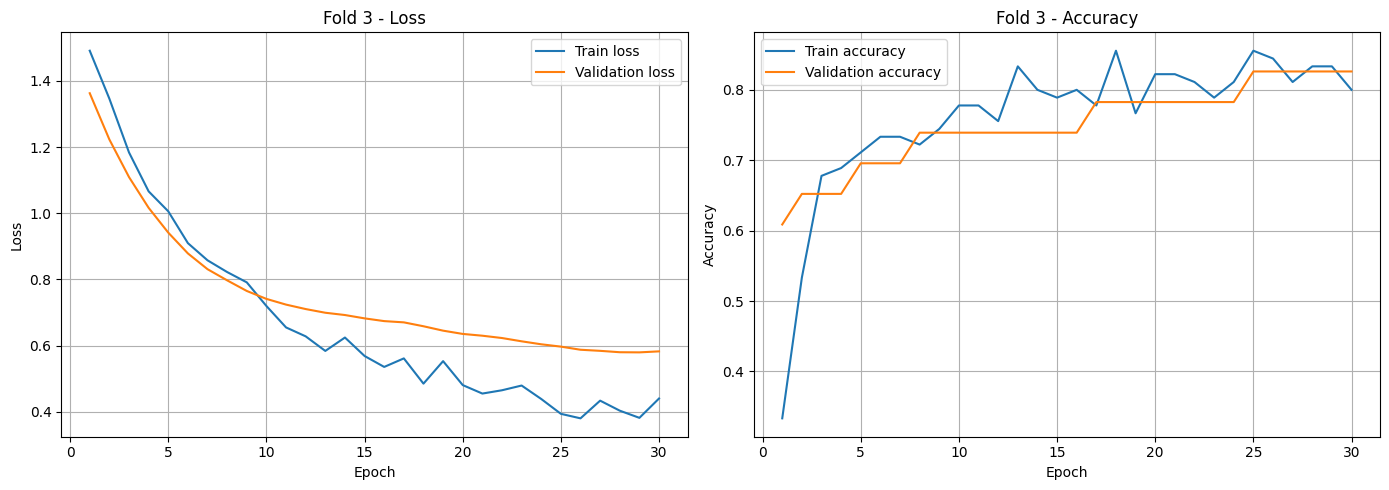

Fold 3: accuracy=0.8261, macro F1=0.5692

========== FOLD 4 ==========
Epoch 5/30 | train_loss=1.2359 | val_loss=1.3336 | train_acc=0.5055 | val_acc=0.5455
Epoch 10/30 | train_loss=0.7858 | val_loss=1.0593 | train_acc=0.8132 | val_acc=0.6364
Epoch 15/30 | train_loss=0.6475 | val_loss=0.9410 | train_acc=0.7582 | val_acc=0.6818
Epoch 20/30 | train_loss=0.5196 | val_loss=0.8986 | train_acc=0.8791 | val_acc=0.7273
Epoch 25/30 | train_loss=0.4577 | val_loss=0.8832 | train_acc=0.8901 | val_acc=0.6818
Epoch 30/30 | train_loss=0.3832 | val_loss=0.8892 | train_acc=0.8901 | val_acc=0.7273


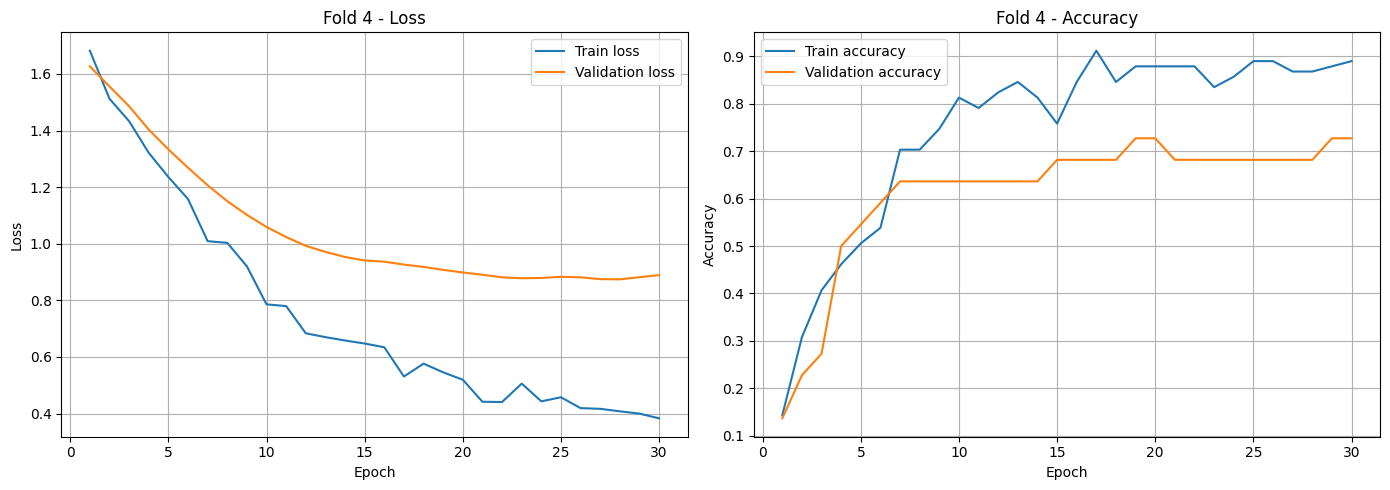

Fold 4: accuracy=0.7273, macro F1=0.4218

========== FOLD 5 ==========
Epoch 5/30 | train_loss=1.1238 | val_loss=1.2181 | train_acc=0.7253 | val_acc=0.6818
Epoch 10/30 | train_loss=0.7827 | val_loss=0.9380 | train_acc=0.8571 | val_acc=0.7273
Epoch 15/30 | train_loss=0.6131 | val_loss=0.8017 | train_acc=0.7912 | val_acc=0.7727
Epoch 20/30 | train_loss=0.4459 | val_loss=0.7389 | train_acc=0.9121 | val_acc=0.7727
Epoch 25/30 | train_loss=0.3446 | val_loss=0.6884 | train_acc=0.9121 | val_acc=0.7727
Epoch 30/30 | train_loss=0.3646 | val_loss=0.6856 | train_acc=0.9011 | val_acc=0.8182


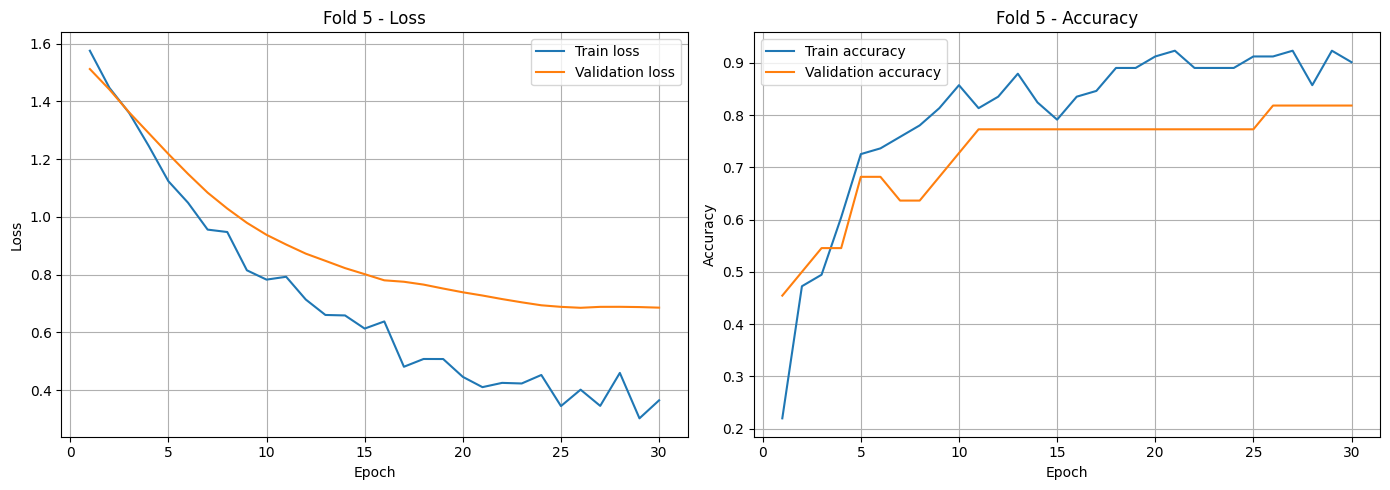

Fold 5: accuracy=0.8182, macro F1=0.6177

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.7787
Mean macro F1: 0.5279
              precision    recall  f1-score   support

        Bach       0.93      0.93      0.93        30
   Beethoven       0.73      0.95      0.83        55
      Brahms       0.00      0.00      0.00         8
      Mozart       0.88      0.64      0.74        11
    Schubert       1.00      0.11      0.20         9

    accuracy                           0.78       113
   macro avg       0.71      0.53      0.54       113
weighted avg       0.77      0.78      0.74       113



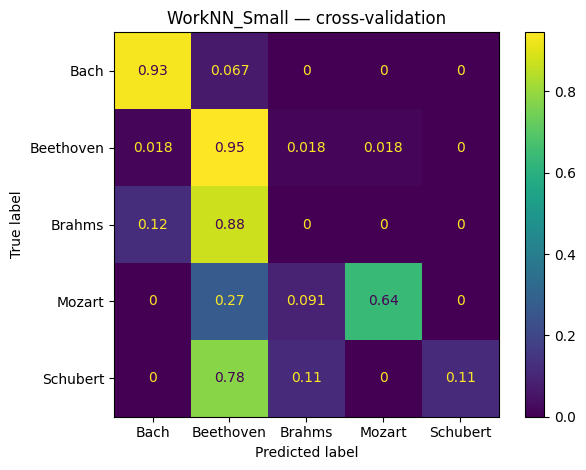

In [ ]:
results_work_small = cross_validate_feature_model(
    WorkNN_Small,
    X_work, y_work,
    epochs=30,
    batch_size=16,
    learning_rate=0.001,
)

In [ ]:
# Vidimo da smo uspjeli da poboljsamo rezultate po pitanju preprilagodjavanja

In [ ]:
class WorkNN_Compact(nn.Module):

    def __init__(self, input_size, num_classes):
        super().__init__()

        self.network = nn.Sequential(
            nn.Linear(input_size, 8),
            nn.ReLU(),
            nn.Dropout(0.5),

            nn.Linear(8, num_classes)
        )

    def forward(self, x):
        return self.network(x)


WorkNN_Compact | device: cpu
Classes: ['Bach' 'Beethoven' 'Brahms' 'Mozart' 'Schubert']

========== FOLD 1 ==========
Epoch 5/60 | train_loss=1.2504 | val_loss=1.2232 | train_acc=0.6111 | val_acc=0.6522
Epoch 10/60 | train_loss=1.0832 | val_loss=0.9921 | train_acc=0.6000 | val_acc=0.6522
Epoch 15/60 | train_loss=0.8667 | val_loss=0.8726 | train_acc=0.6778 | val_acc=0.6957
Epoch 20/60 | train_loss=0.7969 | val_loss=0.8091 | train_acc=0.6889 | val_acc=0.6957
Epoch 25/60 | train_loss=0.7870 | val_loss=0.7796 | train_acc=0.6556 | val_acc=0.6957
Epoch 30/60 | train_loss=0.7302 | val_loss=0.7689 | train_acc=0.7333 | val_acc=0.6957
Epoch 35/60 | train_loss=0.8356 | val_loss=0.7555 | train_acc=0.6111 | val_acc=0.6957
Epoch 40/60 | train_loss=0.6588 | val_loss=0.7545 | train_acc=0.6889 | val_acc=0.6957
Epoch 45/60 | train_loss=0.7017 | val_loss=0.7629 | train_acc=0.6556 | val_acc=0.6957
Epoch 50/60 | train_loss=0.5639 | val_loss=0.7523 | train_acc=0.8111 | val_acc=0.6957
Epoch 55/60 | train_lo

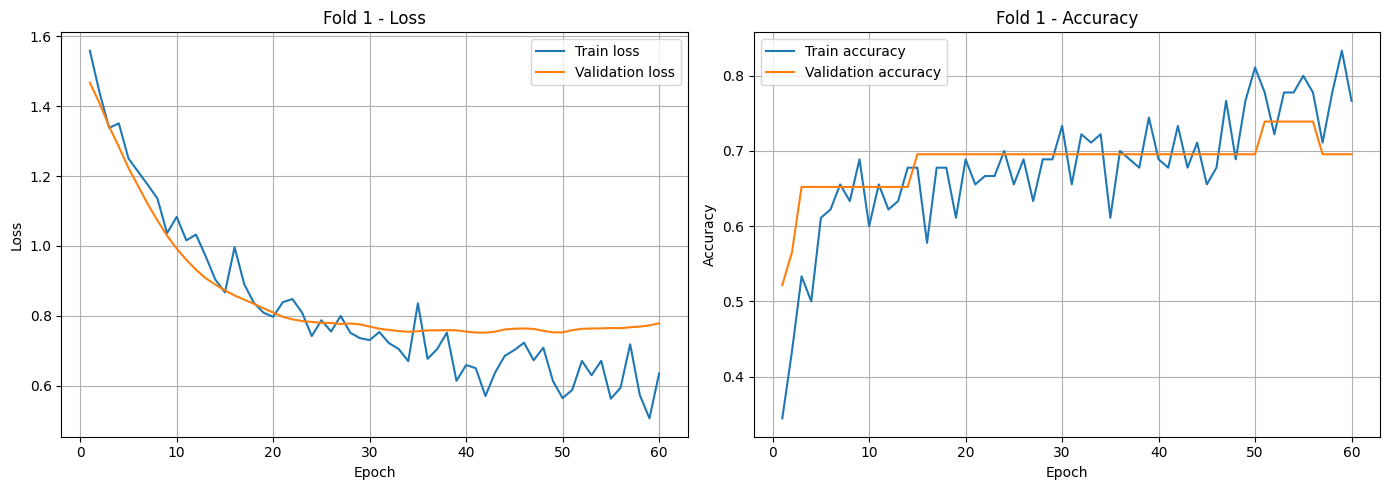

Fold 1: accuracy=0.6957, macro F1=0.3385

========== FOLD 2 ==========
Epoch 5/60 | train_loss=1.2120 | val_loss=1.3594 | train_acc=0.5333 | val_acc=0.5217
Epoch 10/60 | train_loss=0.9026 | val_loss=1.2304 | train_acc=0.6667 | val_acc=0.4783
Epoch 15/60 | train_loss=0.8424 | val_loss=1.1475 | train_acc=0.6778 | val_acc=0.5652
Epoch 20/60 | train_loss=0.7264 | val_loss=1.0746 | train_acc=0.6444 | val_acc=0.6087
Epoch 25/60 | train_loss=0.7004 | val_loss=1.0573 | train_acc=0.7444 | val_acc=0.6522
Epoch 30/60 | train_loss=0.5984 | val_loss=1.0316 | train_acc=0.6889 | val_acc=0.6522
Epoch 35/60 | train_loss=0.6277 | val_loss=1.0663 | train_acc=0.7444 | val_acc=0.6522
Epoch 40/60 | train_loss=0.6201 | val_loss=1.0564 | train_acc=0.7000 | val_acc=0.6522
Epoch 45/60 | train_loss=0.5727 | val_loss=1.0582 | train_acc=0.8000 | val_acc=0.6522
Epoch 50/60 | train_loss=0.5673 | val_loss=1.0733 | train_acc=0.8000 | val_acc=0.6522
Epoch 55/60 | train_loss=0.5697 | val_loss=1.0833 | train_acc=0.7333 |

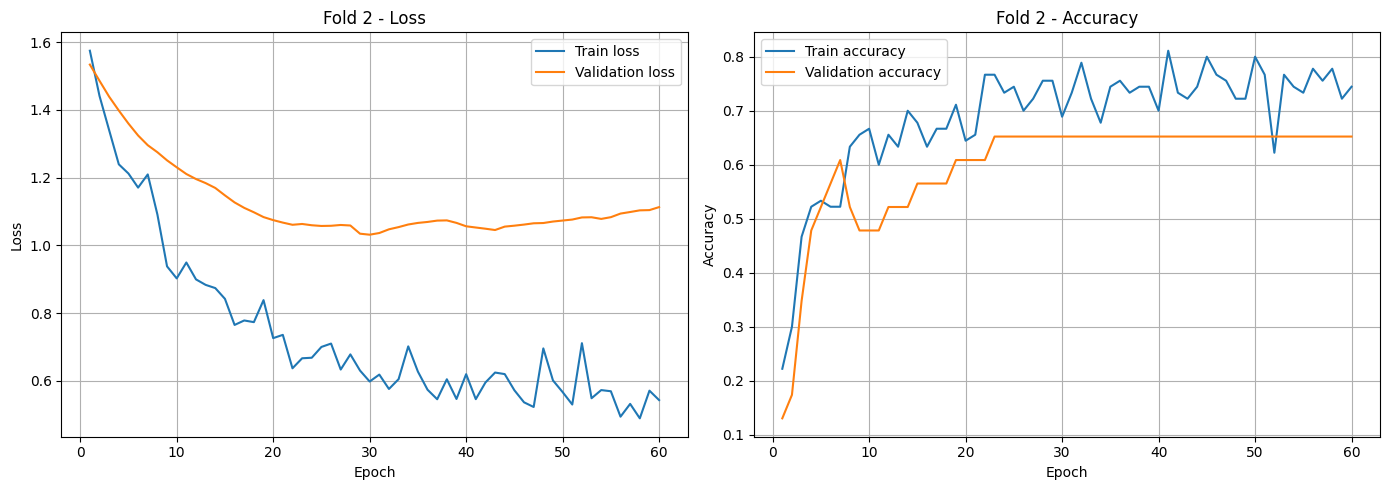

Fold 2: accuracy=0.6522, macro F1=0.2967

========== FOLD 3 ==========
Epoch 5/60 | train_loss=1.3329 | val_loss=1.0906 | train_acc=0.5000 | val_acc=0.7391
Epoch 10/60 | train_loss=0.9814 | val_loss=0.8548 | train_acc=0.7222 | val_acc=0.7391
Epoch 15/60 | train_loss=0.8386 | val_loss=0.7254 | train_acc=0.7333 | val_acc=0.7826
Epoch 20/60 | train_loss=0.8072 | val_loss=0.6400 | train_acc=0.7111 | val_acc=0.8696
Epoch 25/60 | train_loss=0.7626 | val_loss=0.6021 | train_acc=0.7333 | val_acc=0.8261
Epoch 30/60 | train_loss=0.7700 | val_loss=0.5715 | train_acc=0.7222 | val_acc=0.8696
Epoch 35/60 | train_loss=0.5949 | val_loss=0.5516 | train_acc=0.7778 | val_acc=0.8261
Epoch 40/60 | train_loss=0.6794 | val_loss=0.5248 | train_acc=0.7778 | val_acc=0.8261
Epoch 45/60 | train_loss=0.5896 | val_loss=0.5071 | train_acc=0.7667 | val_acc=0.8261
Epoch 50/60 | train_loss=0.5261 | val_loss=0.5171 | train_acc=0.8111 | val_acc=0.8696
Epoch 55/60 | train_loss=0.5786 | val_loss=0.4779 | train_acc=0.7667 |

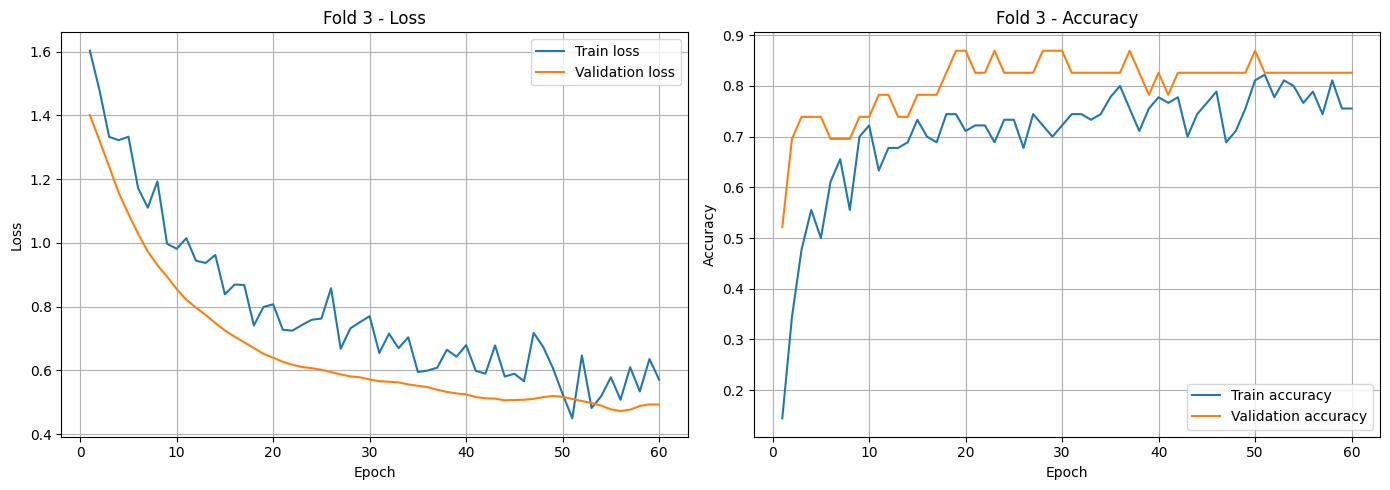

Fold 3: accuracy=0.8261, macro F1=0.7236

========== FOLD 4 ==========
Epoch 5/60 | train_loss=1.3096 | val_loss=1.3033 | train_acc=0.4286 | val_acc=0.5909
Epoch 10/60 | train_loss=1.0845 | val_loss=1.0653 | train_acc=0.5824 | val_acc=0.6364
Epoch 15/60 | train_loss=0.9777 | val_loss=0.9559 | train_acc=0.5824 | val_acc=0.6364
Epoch 20/60 | train_loss=0.7205 | val_loss=0.9002 | train_acc=0.7363 | val_acc=0.6364
Epoch 25/60 | train_loss=0.7430 | val_loss=0.8695 | train_acc=0.7033 | val_acc=0.6364
Epoch 30/60 | train_loss=0.7655 | val_loss=0.8627 | train_acc=0.6703 | val_acc=0.6364
Epoch 35/60 | train_loss=0.7262 | val_loss=0.8478 | train_acc=0.7582 | val_acc=0.6818
Epoch 40/60 | train_loss=0.7436 | val_loss=0.8633 | train_acc=0.6484 | val_acc=0.6818
Epoch 45/60 | train_loss=0.7085 | val_loss=0.8542 | train_acc=0.6703 | val_acc=0.7273
Epoch 50/60 | train_loss=0.7779 | val_loss=0.8813 | train_acc=0.6154 | val_acc=0.6818
Epoch 55/60 | train_loss=0.5563 | val_loss=0.9004 | train_acc=0.7582 |

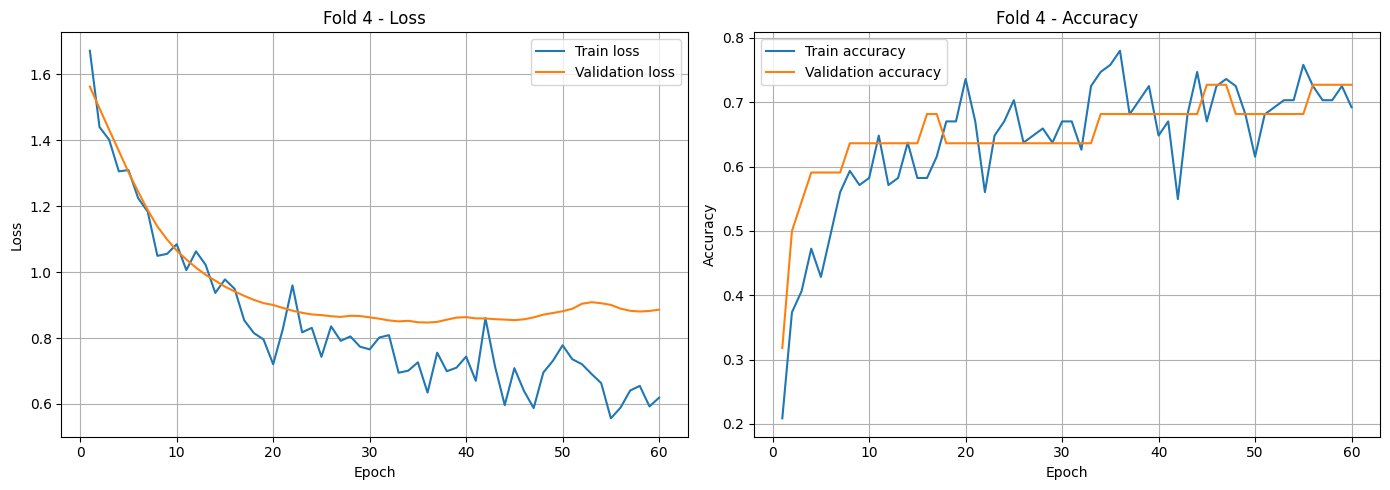

Fold 4: accuracy=0.7273, macro F1=0.4067

========== FOLD 5 ==========
Epoch 5/60 | train_loss=1.3000 | val_loss=1.3033 | train_acc=0.4615 | val_acc=0.5909
Epoch 10/60 | train_loss=0.9457 | val_loss=1.0387 | train_acc=0.6484 | val_acc=0.7727
Epoch 15/60 | train_loss=0.6944 | val_loss=0.9747 | train_acc=0.7363 | val_acc=0.6818
Epoch 20/60 | train_loss=0.6540 | val_loss=0.8816 | train_acc=0.7692 | val_acc=0.6818
Epoch 25/60 | train_loss=0.8079 | val_loss=0.8366 | train_acc=0.6044 | val_acc=0.6364
Epoch 30/60 | train_loss=0.6881 | val_loss=0.8236 | train_acc=0.7253 | val_acc=0.6364
Epoch 35/60 | train_loss=0.6773 | val_loss=0.7939 | train_acc=0.7363 | val_acc=0.6364
Epoch 40/60 | train_loss=0.5982 | val_loss=0.7749 | train_acc=0.7363 | val_acc=0.6364
Epoch 45/60 | train_loss=0.6642 | val_loss=0.7835 | train_acc=0.7033 | val_acc=0.6818
Epoch 50/60 | train_loss=0.5645 | val_loss=0.7607 | train_acc=0.7582 | val_acc=0.6818
Epoch 55/60 | train_loss=0.4833 | val_loss=0.7521 | train_acc=0.7912 |

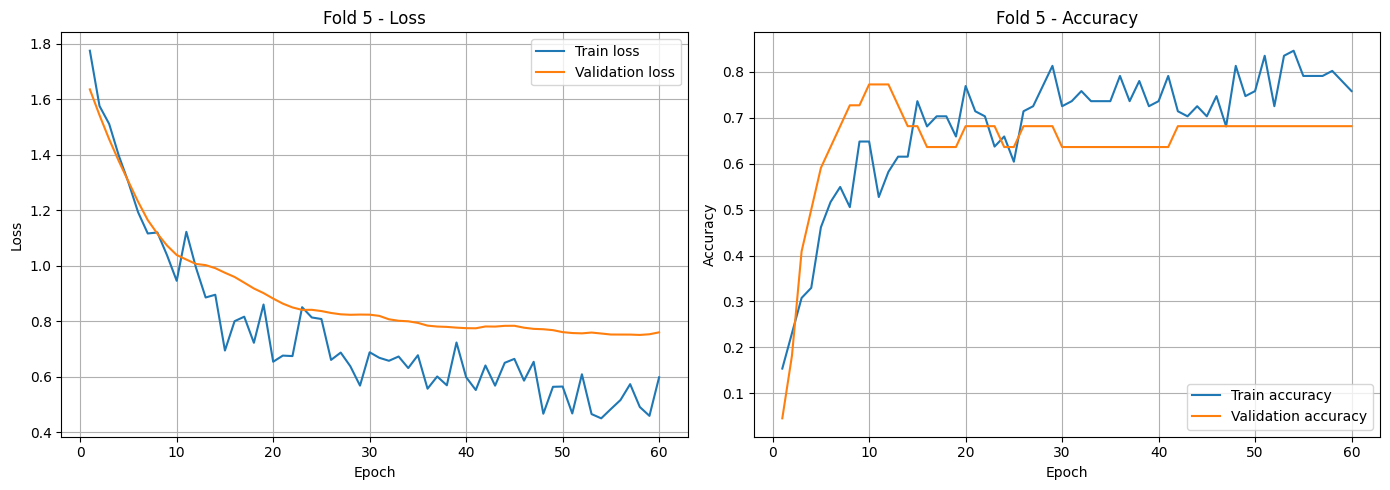

Fold 5: accuracy=0.6818, macro F1=0.3267

========== UKUPNI REZULTATI ==========
Mean accuracy: 0.7166
Mean macro F1: 0.4184
              precision    recall  f1-score   support

        Bach       0.82      0.90      0.86        30
   Beethoven       0.71      0.89      0.79        55
      Brahms       0.67      0.25      0.36         8
      Mozart       0.60      0.27      0.38        11
    Schubert       0.00      0.00      0.00         9

    accuracy                           0.72       113
   macro avg       0.56      0.46      0.48       113
weighted avg       0.67      0.72      0.67       113



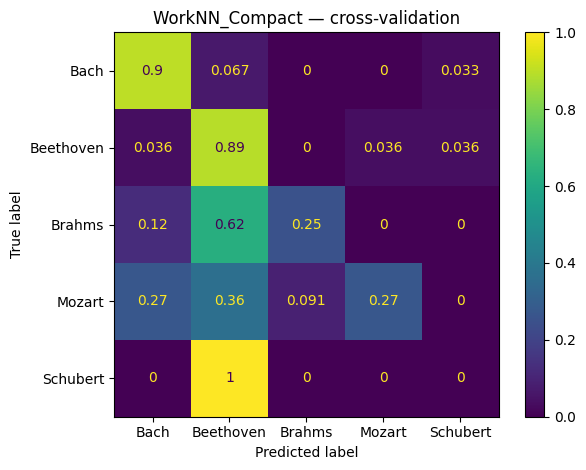

In [ ]:
results_work_compact = cross_validate_neural_network(
    WorkNN_Compact,
    X_work, y_work,
    epochs=60,
    batch_size=16,
    learning_rate=0.001,
    weight_decay=1e-4,
)

<span style="font-size:20px">
Dakle, uspjeli smo da se mreza ne preprilagodi toliko podacima, ali smo morali da uzmemo jako malu mrezu sto nam je umanjilo prediktivne sposobnosti znacajno u ovako teskom problemu klasifikacije
</span>